# Theoretical Questions

# 1. What is unsupervised learning in the context of machine learning?

Unsupervised learning is a type of machine learning where the model learns patterns from unlabeled data without explicit supervision.
It aims to discover hidden structures or relationships within the data, such as grouping similar data points (clustering) or reducing dimensionality.

# 2. How does K-Means clustering algorithm work?

K-Means is an iterative algorithm that partitions data into K clusters by minimizing the distance between data points and cluster centroids:
1. Initialize K centroids randomly.
2. Assign each data point to the nearest centroid.
3. Recompute centroids as the mean of assigned points.
4. Repeat steps 2-3 until convergence (no changes in assignments).


# 3. Explain the concept of a dendrogram in hierarchical clustering.

A dendrogram is a tree-like diagram used in hierarchical clustering to represent the arrangement of clusters. It shows how clusters are merged or split hierarchically and helps determine the optimal number of clusters by identifying significant gaps in linkage distances.

# 4. What is the main difference between K-Means and Hierarchical Clustering?
K-Means requires specifying the number of clusters (K) beforehand and uses a partitioning approach. Hierarchical clustering builds a hierarchy of clusters without requiring K and can be agglomerative (bottom-up) or divisive (top-down).


# 5. What are the advantages of DBSCAN over K-Means?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
- Can find arbitrarily shaped clusters.
- Handles noise and outliers effectively.
- Does not require specifying the number of clusters.
- Works well with varying cluster densities.


# 6. When would you use Silhouette Score in clustering?

The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters. It is used to evaluate clustering quality and determine the optimal number of clusters (higher scores indicate better-defined clusters).


# 7. What are the limitations of Hierarchical Clustering?

- Computationally expensive for large datasets (O(n^2) or O(n^3)).
- Sensitive to noise and outliers.
- Once clusters are merged or split, they cannot be undone.


# 8. Why is feature scaling important in clustering algorithms like K-Means?

Feature scaling ensures that all features contribute equally to distance calculations. Without scaling, features with larger ranges dominate the distance metric, leading to biased clustering results.


# 9. How does DBSCAN identify noise points?

DBSCAN identifies noise points as data points that do not belong to any cluster. These points are either too far from core points or do not meet the minimum density requirement (min_samples).


# 10. Define inertia in the context of K-Means.

Inertia is the sum of squared distances between each data point and its assigned cluster centroid. Lower inertia indicates better clustering, but it decreases monotonically with increasing K.


# 11. What is the elbow method in K-Means clustering?

The elbow method plots inertia against the number of clusters (K). The "elbow" point, where the rate of decrease in inertia slows down, is chosen as the optimal number of clusters.

# 12. Describe the concept of "density" in DBSCAN.

Density refers to the number of points within a specified radius (eps) around a data point. Core points have sufficient neighbors (>= min_samples), while border points are close to core points but do not meet the density requirement.


# 13. Can hierarchical clustering be used on categorical data?

Hierarchical clustering can be used on categorical data if an appropriate distance metric (e.g., Jaccard, Hamming) is used. However, preprocessing may be required to handle non-numeric features.

# 14. What does a negative Silhouette Score indicate?

A negative Silhouette Score indicates that a data point is closer to another cluster than its own, suggesting poor clustering or overlapping clusters.


# 15. Explain the term "linkage criteria" in hierarchical clustering.

Linkage criteria define how the distance between clusters is calculated during merging:
- Single Linkage: Minimum distance between clusters.
- Complete Linkage: Maximum distance between clusters.
- Average Linkage: Average distance between clusters.
- Ward's Method: Minimizes variance increase when merging clusters.


# 16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

K-Means assumes spherical clusters of similar size and density. It struggles with irregularly shaped clusters or varying densities because it minimizes Euclidean distances to centroids.


# 17. What are the core parameters in DBSCAN, and how do they influence clustering?

- eps: Defines the radius for neighborhood search. Larger values merge more points into clusters.
- min_samples: Sets the minimum number of points required to form a dense region. Smaller values allow smaller clusters.


# 18. How does K-Means++ improve upon standard K-Means initialization?

K-Means++ initializes centroids by spreading them farther apart, reducing the likelihood of poor clustering due to bad initial centroid placement.

# 19. What is agglomerative clustering?

Agglomerative clustering is a bottom-up hierarchical clustering approach. It starts with each data point as a single cluster and iteratively merges the closest clusters until a stopping criterion is met.


# 20. What makes Silhouette Score a better metric than just inertia for model evaluation?

Silhouette Score evaluates both cohesion (within-cluster similarity) and separation (between-cluster dissimilarity), providing a more holistic measure of clustering quality compared to inertia, which only considers distances to centroids.

# Practical Section

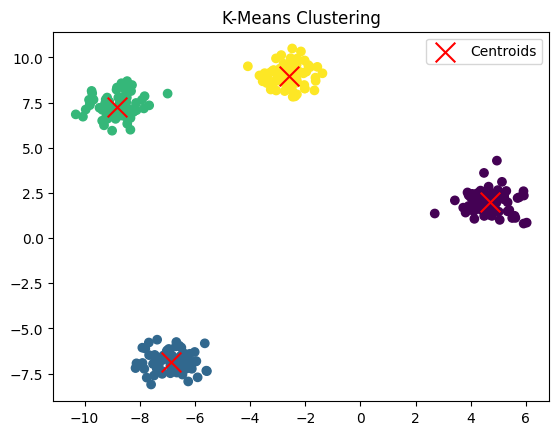

In [1]:
# 21. Generate synthetic data with 4 centers using `make_blobs` and apply K-Means clustering. Visualize using a scatter plot
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
kmeans = KMeans(n_clusters=4)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [2]:
# 22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(iris.data)
print("First 10 Predicted Labels:", labels[:10])

First 10 Predicted Labels: [1 1 1 1 1 1 1 1 1 1]


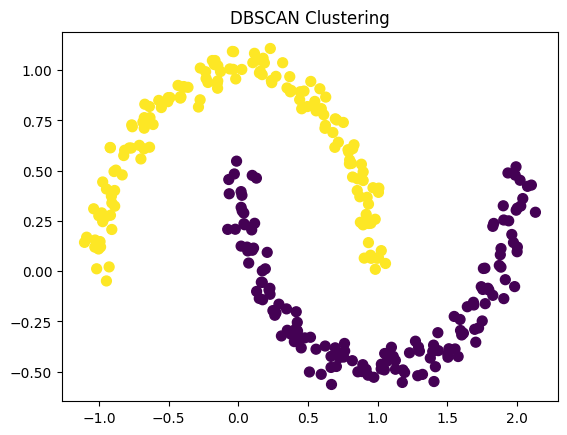

In [3]:
# 23. Generate synthetic data using `make_moons` and apply DBSCAN. Highlight outliers in the plot
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering")
plt.show()

In [4]:
# 24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

wine = load_wine()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
print("Cluster Sizes:", {i: (labels == i).sum() for i in range(3)})

Cluster Sizes: {0: np.int64(65), 1: np.int64(51), 2: np.int64(62)}


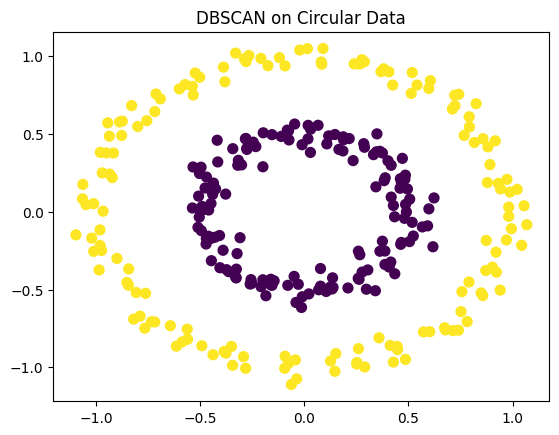

In [5]:
# 25. Use `make_circles` to generate synthetic data and cluster it using DBSCAN. Plot the result
from sklearn.datasets import make_circles

X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN on Circular Data")
plt.show()

In [6]:
# 26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(cancer.data)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
print("Cluster Centroids:\n", kmeans.cluster_centers_)

Cluster Centroids:
 [[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


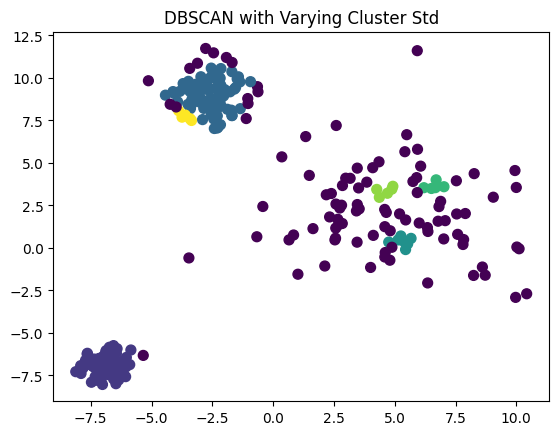

In [7]:
# 27. Generate synthetic data using `make_blobs` with varying cluster standard deviations and cluster with DBSCAN
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN with Varying Cluster Std")
plt.show()

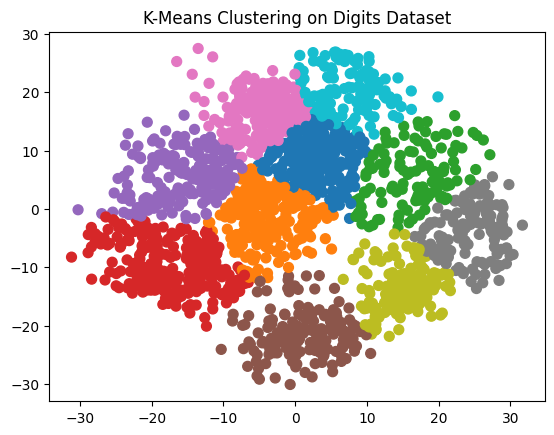

In [8]:
# 28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=50)
plt.title("K-Means Clustering on Digits Dataset")
plt.show()

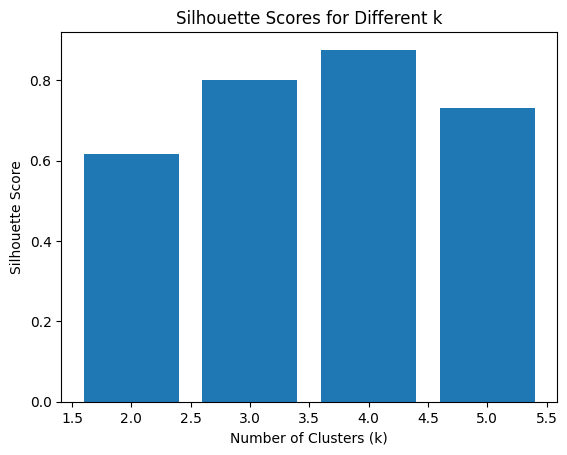

In [9]:
# 29. Create synthetic data using `make_blobs` and evaluate silhouette scores for k = 2 to 5. Display as a bar chart
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
sil_scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.bar(range(2, 6), sil_scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.show()

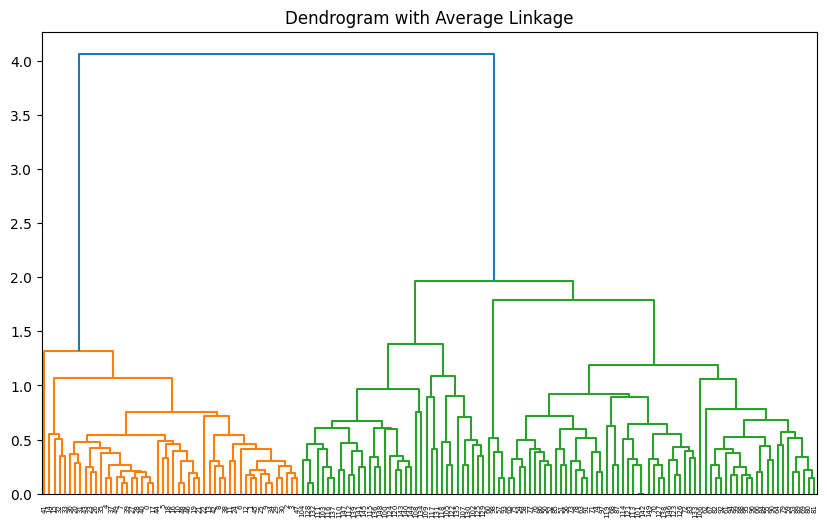

In [10]:
# 30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
Z = linkage(iris.data, method='average')
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram with Average Linkage")
plt.show()

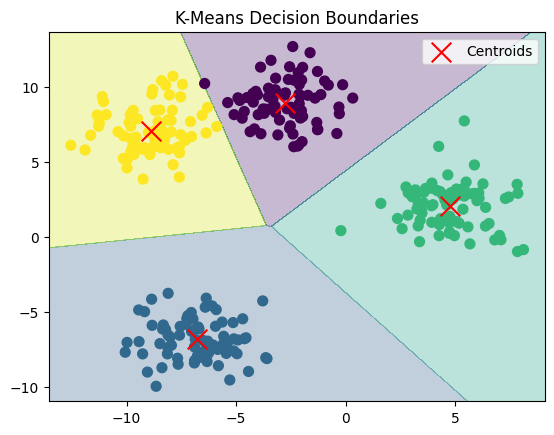

In [29]:
# 31. Generate synthetic data with overlapping clusters using `make_blobs`, then apply K-Means and visualize with decision boundaries
from sklearn.datasets import make_blobs
import numpy as np

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=42)
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Plotting decision boundaries
h = 0.02  # Step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title("K-Means Decision Boundaries")
plt.legend()
plt.show()

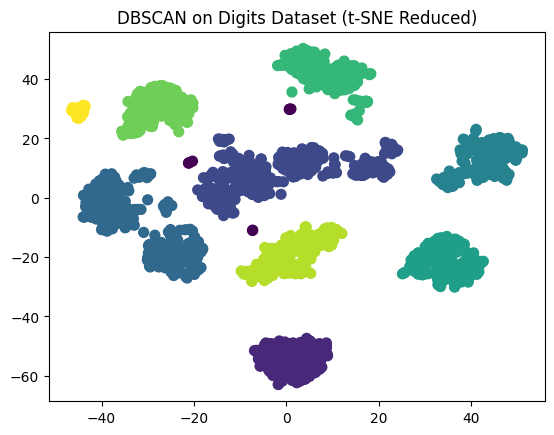

In [12]:
# 32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results
from sklearn.manifold import TSNE

digits = load_digits()
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(digits.data)

dbscan = DBSCAN(eps=5, min_samples=10)
labels = dbscan.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN on Digits Dataset (t-SNE Reduced)")
plt.show()

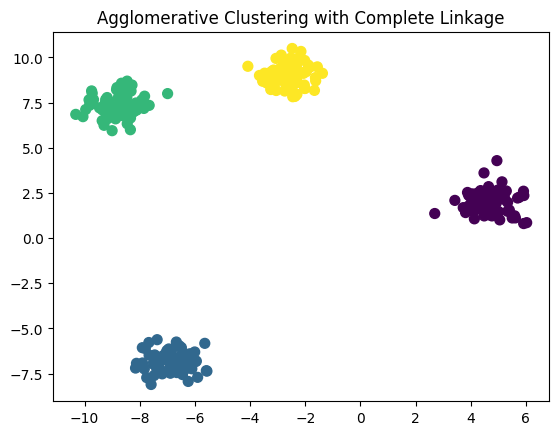

In [13]:
# 33. Generate synthetic data using `make_blobs` and apply Agglomerative Clustering with complete linkage. Plot the result
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
agg = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering with Complete Linkage")
plt.show()

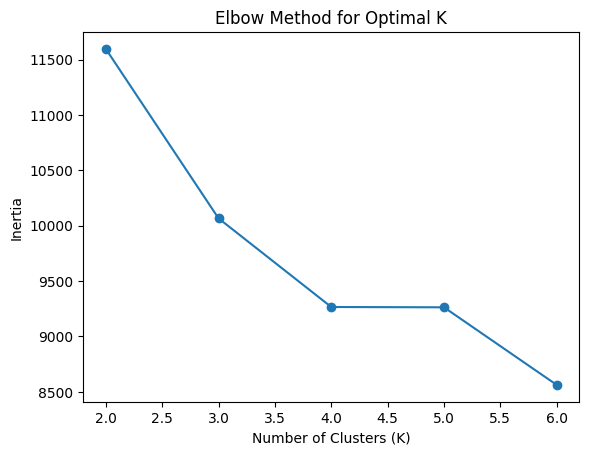

In [14]:
# 34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot
cancer = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cancer.data)

inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(2, 7), inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

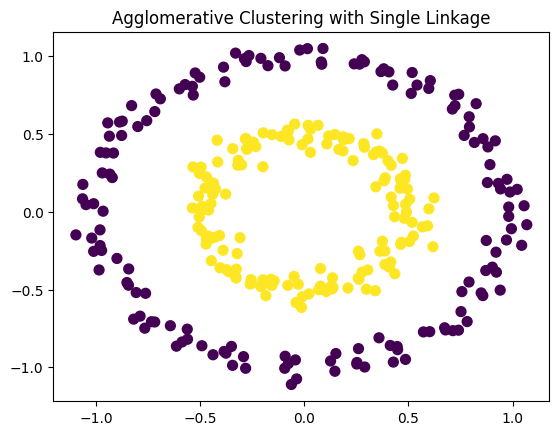

In [15]:
# 35. Generate synthetic concentric circles using `make_circles` and cluster using Agglomerative Clustering with single linkage
X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering with Single Linkage")
plt.show()

In [16]:
# 36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)
wine = load_wine()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of Clusters (Excluding Noise):", n_clusters)

Number of Clusters (Excluding Noise): 0


In [17]:
# 36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)
wine = load_wine()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)

dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of Clusters (Excluding Noise):", n_clusters)

Number of Clusters (Excluding Noise): 0


In [18]:
# 38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise
iris = load_iris()
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(iris.data)

noise_count = (labels == -1).sum()
print("Number of Noise Points:", noise_count)

Number of Noise Points: 17


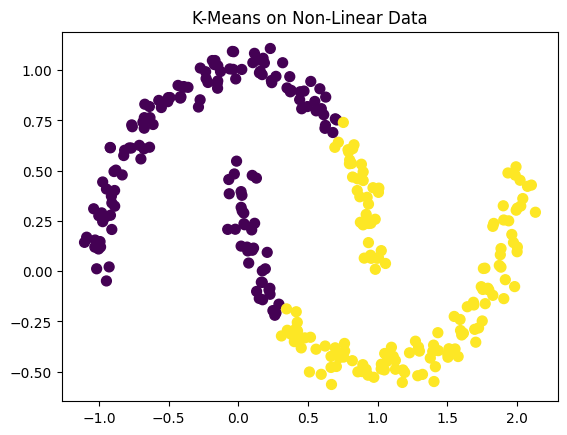

In [19]:
# 39. Generate synthetic non-linearly separable data using `make_moons`, apply K-Means, and visualize the clustering result
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("K-Means on Non-Linear Data")
plt.show()

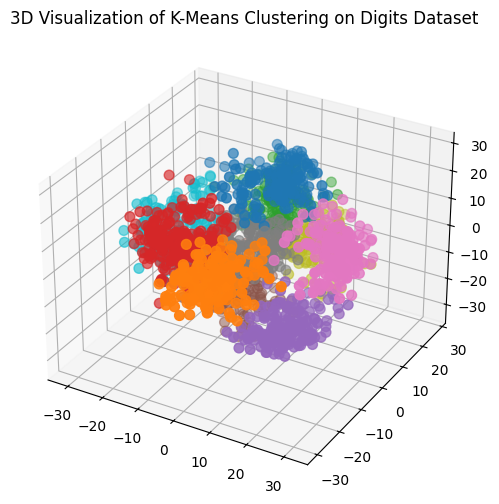

In [20]:
# 40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot
pca = PCA(n_components=3)
X_pca = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='tab10', s=50)
plt.title("3D Visualization of K-Means Clustering on Digits Dataset")
plt.show()

In [21]:
# 41. Generate synthetic blobs with 5 centers and apply KMeans. Then use `silhouette_score` to evaluate the clustering
X, _ = make_blobs(n_samples=300, centers=5, cluster_std=0.6, random_state=42)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

sil_score = silhouette_score(X, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.7945138706672983


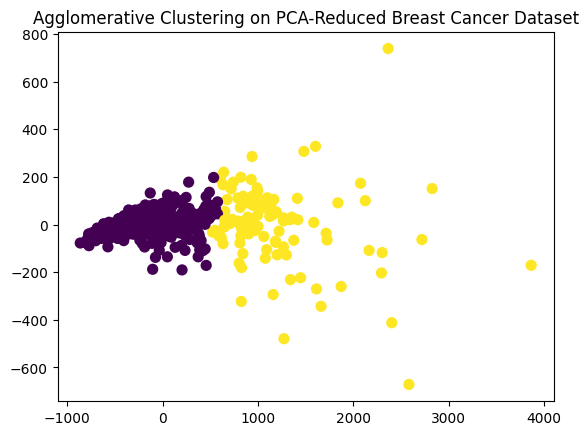

In [22]:
# 42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D
cancer = load_breast_cancer()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cancer.data)

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering on PCA-Reduced Breast Cancer Dataset")
plt.show()

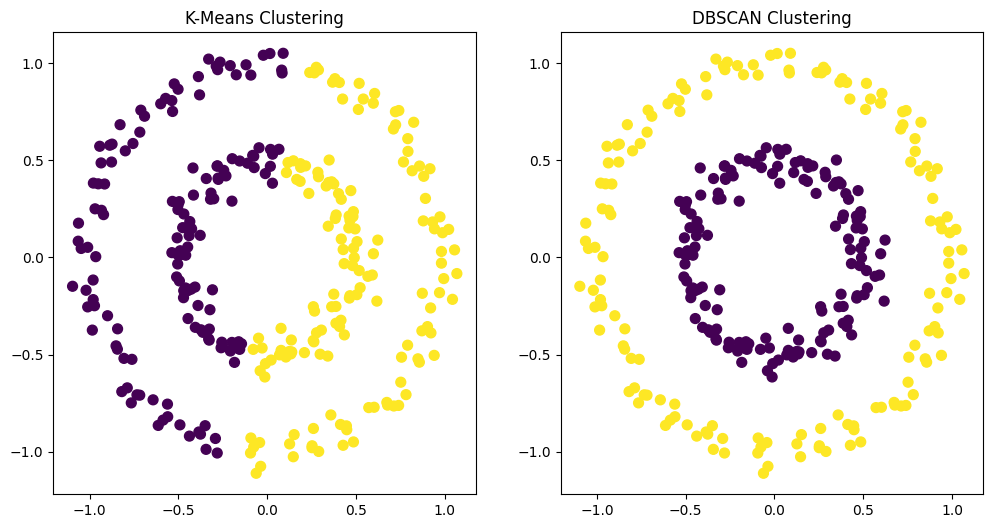

In [23]:
# 43. Generate noisy circular data using `make_circles` and visualize clustering results from KMeans and DBSCAN side-by-side
X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50)
axes[0].set_title("K-Means Clustering")
axes[1].scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', s=50)
axes[1].set_title("DBSCAN Clustering")
plt.show()

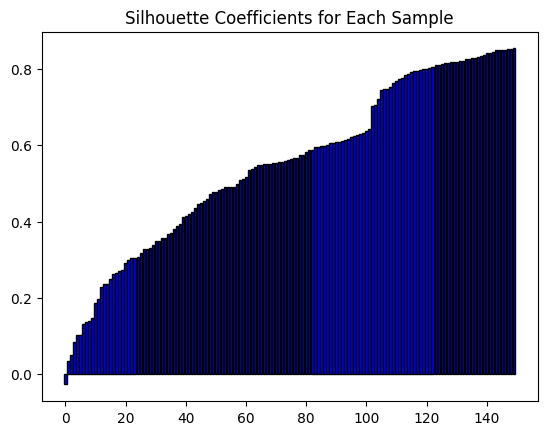

In [24]:
# 44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering
iris = load_iris()
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(iris.data)

from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(iris.data, labels)

plt.bar(range(len(silhouette_vals)), sorted(silhouette_vals), color='blue', edgecolor='k')
plt.title("Silhouette Coefficients for Each Sample")
plt.show()

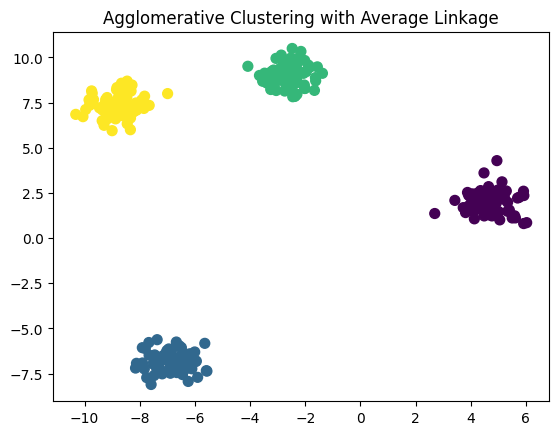

In [25]:
# 45. Generate synthetic data using `make_blobs` and apply Agglomerative Clustering with 'average' linkage. Visualize clusters
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering with Average Linkage")
plt.show()

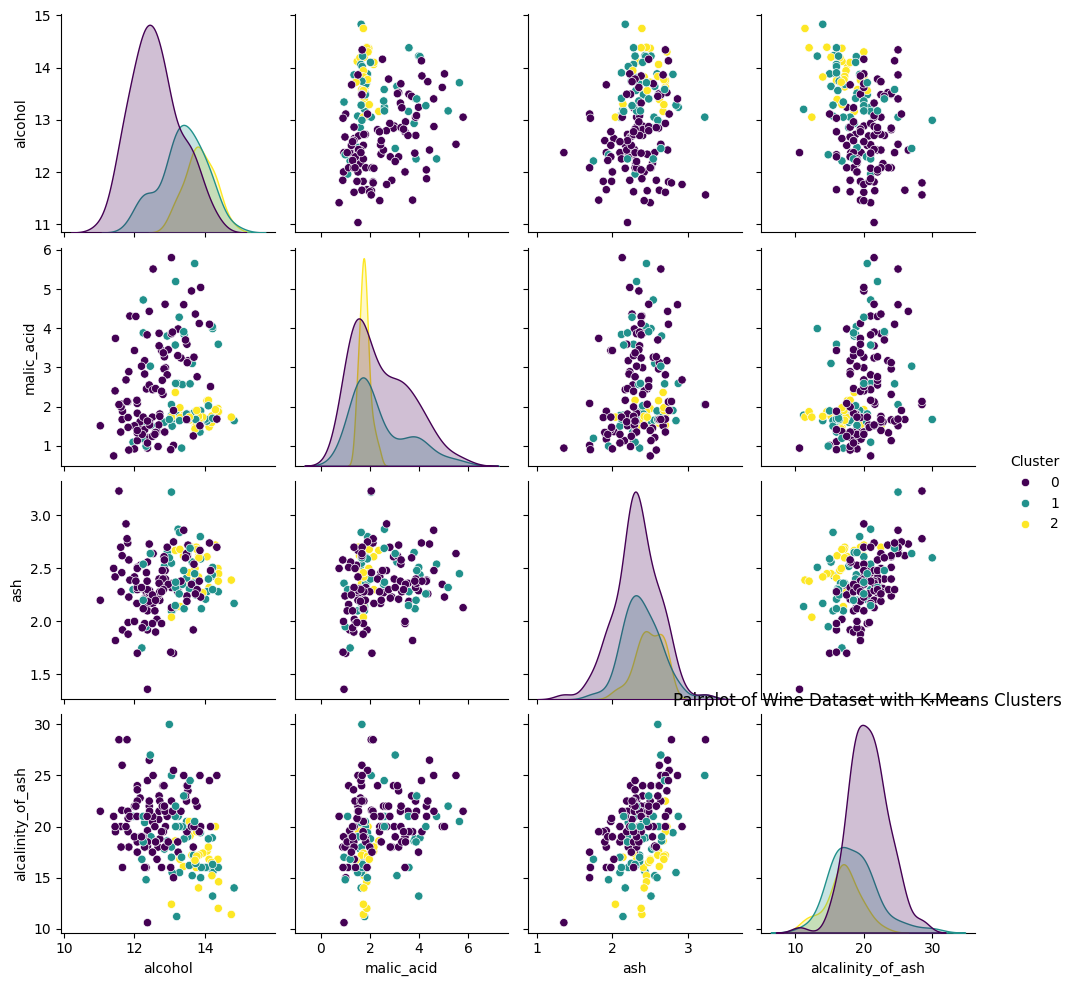

In [26]:
# 46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features)
wine = load_wine()
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(wine.data)

import pandas as pd
import seaborn as sns

df = pd.DataFrame(wine.data[:, :4], columns=wine.feature_names[:4])
df['Cluster'] = labels

sns.pairplot(df, hue='Cluster', palette='viridis')
plt.title("Pairplot of Wine Dataset with K-Means Clusters")
plt.show()

In [27]:
# 47. Generate noisy blobs using `make_blobs` and use DBSCAN to identify both clusters and noise points. Print the count
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=42)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_count = (labels == -1).sum()
print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", noise_count)

Number of Clusters: 10
Number of Noise Points: 182


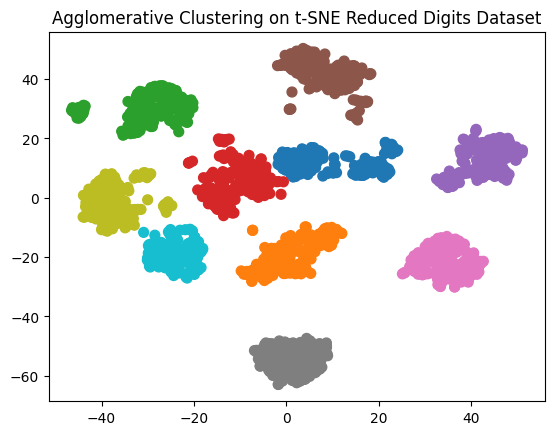

In [28]:
# 48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters
digits = load_digits()
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(digits.data)

agg = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = agg.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=50)
plt.title("Agglomerative Clustering on t-SNE Reduced Digits Dataset")
plt.show()